# **Analyzing and plotting the evolutionary ownership game**

Two individuals contest a resource. It could be a territory, a breeding site, or a food item (we will focus on the interpretation where the resource is a territory in this notebook). Whether it pays to fight or yield depends on what others in the population do. This notebook builds from the simplest two-strategy conflict to a four-strategy model that includes an ownership convention, using the replicator dynamics and pyNamo's phase-portrait tools at each step.

## Setup

The notebook uses pyNamo's public interface to analyze and plot the replicator dynamics when the underlying game is the ownership game defined by Maynard Smith and Price (1973).

In [1]:
#Installing pynamo-egt to plot replicator dynamics phase portraits
!pip install -q pynamo-egt
!pip install -q ipympl

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pynamo_egt as pn

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
})

## The Hawk-Dove game

The standard Hawk-Dove game considers two strategies: Hawk escalates until it wins or is injured, Dove retreats immediately if the opponent escalates. When two individuals meet, the expected payoffs depend on the resource value $V > 0$ and the cost of escalation $C > 0$:

$$
A_{HD} = \begin{pmatrix} \tfrac{V-C}{2} & V \\ 0 & \tfrac{V}{2} \end{pmatrix},
\qquad \text{rows and columns ordered as }(H, D).
$$

When two Hawks meet, one wins (gaining $V$) and the other is injured (paying $-C$), each with probability $1/2$, giving expected payoff $(V-C)/2$. When $C > V$, neither pure strategy is stable. The unique interior equilibrium is $x_H^* = V/C$, and it is the ESS (Maynard Smith 1982). When $C \le V$, escalation always pays and Hawk is the ESS.

In the standard parametrization $C > V$, so the portrait below uses $V = 2$, $C = 3$.

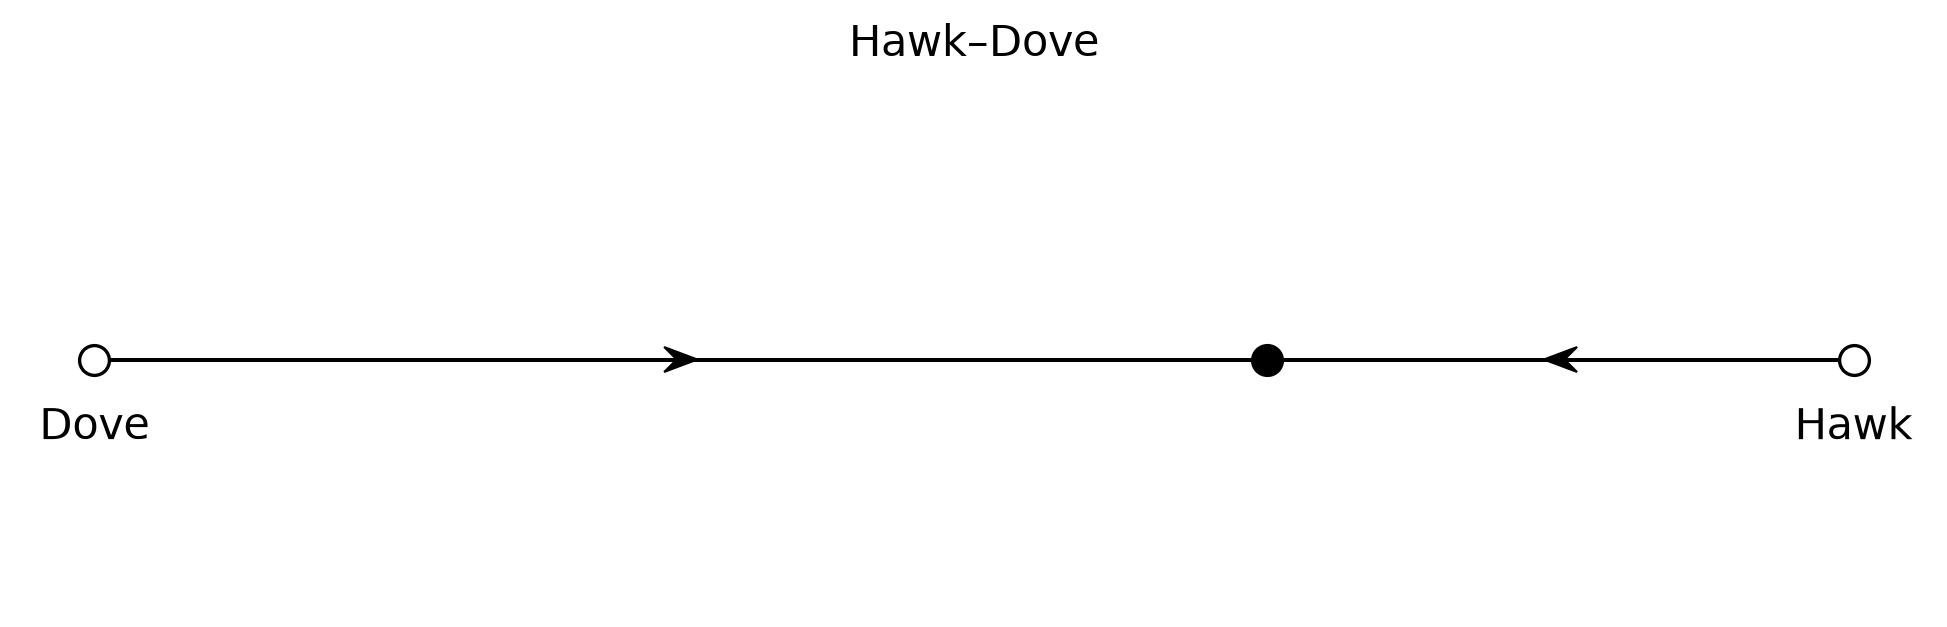

,Position,Stability Status,Nash,ESS,Strict Nash,Eigenvalues,Eigenvectors,Warning
0,"[0.0, 1.0]",source,False,False,False,[1.0],[[1.0]],None
1,"[0.666667, 0.333333]",sink,True,True,False,[-0.333333],[[1.0]],None
2,"[1.0, 0.0]",source,False,False,False,[0.5],[[1.0]],None


In [3]:
plt.close("all")
V, C = 2.0, 3.0

hawk_dove = pn.Game(
    name="Hawk–Dove",
    payoffs=np.array([
        [(V - C) / 2, V],
        [0,           V / 2],
    ]),
    strategy_labels=["Hawk", "Dove"],
)

fig, ax = pn.phase_portrait(
    game=hawk_dove,
    show_edge_flow=True,
    tmax=80,
    figsize=(8, 2.5),
)
plt.show()
pn.equilibrium_table(game=hawk_dove)

The filled marker at $x_H = V/C = 2/3 \approx 0.67$ is the unique interior ESS. Every interior trajectory converges to it, confirming that the coexistence is the long-run outcome when escalation is costly.

Note that at such an equilibrium since there is a positive share of Hawks, violent conflict will occur whenever two Hawks interact.

## Introducing an ownership asymmetry and the Bourgeois strategy

Let's assume now that either of the animals "owns" the territory before the constest. We can then introduce the Bourgeois strategy that behaves as Hawk when it owns the resource and Dove when it intrudes. Assuming owner and intruder roles occur with equal probability gives the matrix below.

$$
A_{\mathrm{HDB}}=
\begin{pmatrix}
(V-C)/2 & V & (3V-C)/4 \\
0 & V/2 & V/4 \\
(V-C)/4 & 3V/4 & V/2
\end{pmatrix},
\qquad \text{rows and columns ordered as }(H,D,B).
$$

Bourgeois resolves the Hawk–Dove conflict by conditioning behaviour on ownership. When Bourgeois is common, a Hawk wins only as owner; as intruder it escalates against another escalator and pays the injury cost on average. Dove concedes the resource in every encounter with a Bourgeois owner. Both resident strategies are therefore invaded by Bourgeois, which is the unique ESS for $0 < V < C$.

The Hawk–Dove mixed equilibrium persists on the Hawk–Dove edge — where Bourgeois is absent and the dynamics reduce to the earlier one-dimensional game — but it becomes a saddle in the full triangle. Any trajectory that introduces even a small fraction of Bourgeois is deflected toward pure Bourgeois. The portrait shows convergence from all three faces of the triangle, with trajectories originating near the Hawk–Dove edge curving away from the saddle and toward the Bourgeois vertex.

Note that when the population reaches the Bourgeois ESS, all individuals use Bourgeois and violent conflicts essentially no longer occur. Whenver an intruder finds itself on the territory of an owner, it will yield and the owner will keep its territory.



/Users/slimane/Documents/GitHub/football-aggression-index/.venv-football-aggression-index/lib/python3.13/site-packages/pynamo_egt/drawer.py:748: InconclusiveStabilityWarning: Stability classification is inconclusive for equilibrium [0.6666666667, 0.3333333333, 0.0]: admissible linearization has eigenvalues with zero real part or unsupported eigendirections, and the implemented fallback did not establish asymptotic stability.
  result = analysis.analyze_equilibria(payoff_data)


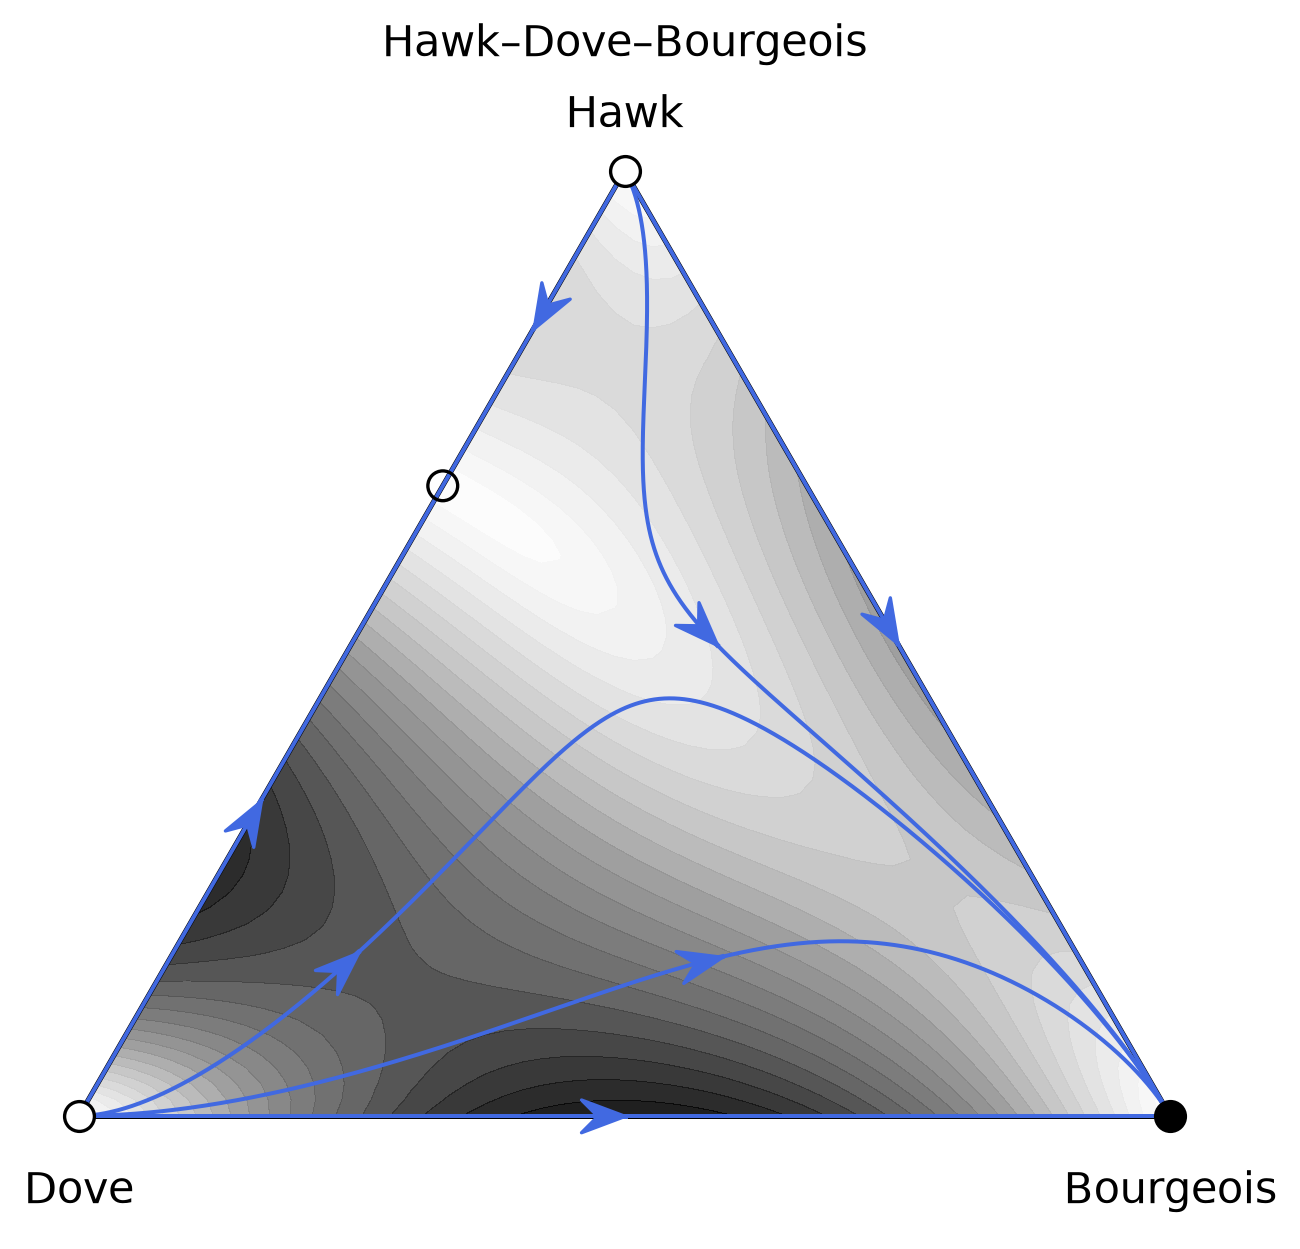

/Users/slimane/Documents/GitHub/football-aggression-index/.venv-football-aggression-index/lib/python3.13/site-packages/pynamo_egt/analysis.py:262: InconclusiveStabilityWarning: Stability classification is inconclusive for equilibrium [0.6666666667, 0.3333333333, 0.0]: admissible linearization has eigenvalues with zero real part or unsupported eigendirections, and the implemented fallback did not establish asymptotic stability.
  return analyze_equilibria(game).to_dataframe(ndigits=ndigits)


,Position,Stability Status,Nash,ESS,Strict Nash,Eigenvalues,Eigenvectors,Warning
0,"[0.0, 0.0, 1.0]",sink,True,True,True,"[-0.25, -0.5]","[[1.0, 0.0], [0.0, 1.0]]",NaN
1,"[0.0, 1.0, 0.0]",source,False,False,False,"[0.5, 1.0]","[[0.0, 1.0], [0.707107, -0.707107]]",NaN
2,"[0.666667, 0.333333, 0.0]",undetermined,True,False,False,"[-0.0, -0.333333]","[[0.707107, 0.707107], [-0.707107, 0.707107]]",Stability classification is inconclusive for e...
3,"[1.0, 0.0, 0.0]",source,False,False,False,"[0.25, 0.5]","[[1.0, 0.0], [-0.707107, 0.707107]]",NaN


In [4]:
V, C = 2.0, 3.0
ownership_payoffs = np.asarray(pn.examples.games.ownership_game.payoff_data, dtype=float)

hawk_dove_bourgeois = pn.Game(
    name="Hawk–Dove–Bourgeois",
    payoffs=ownership_payoffs[:3, :3],
    strategy_labels=["Hawk", "Dove", "Bourgeois"],
)

fig, ax = pn.phase_portrait(
    game=hawk_dove_bourgeois,
    trajectory_number=3,
    #starts=[[0.70, 0.20], [0.20, 0.70], [0.15, 0.15], [0.40, 0.10]],
    show_edge_flow=True,
    tmax=80,
    speed_cmap=plt.cm.Greys,
    speed_levels=20,
    trajectory_arrows=[0.001],
    trajectory_color="royalblue",
    trajectory_zorder=35,
    figsize=(7, 6),
)
plt.show()
pn.equilibrium_table(game=hawk_dove_bourgeois)

## Capstone: Hawk–Dove–Bourgeois–Anti-Bourgeois

Even though Bourgeois under ownership asymmetry "solves" the problem of violent conflicts, it leaves the strategy space not fully explored. If we wanted to define all possible strategies with respect to territory ownership, we would have to also consider the opposite of Bourgeois: Escalate as intruder and retreat as owner. Let's call this strategy Anti-bourgeois.

Adding Anti-Bourgeois turns the problem into one of convention selection. Each strategy is self-reinforcing: when Bourgeois is common, an Anti-Bourgeois individual always fights when at a disadvantage and concedes when it has the advantage, earning badly on average. The reverse holds when Anti-Bourgeois is common. Both pure strategies are therefore stable, and the population's long-run fate depends entirely on its initial composition — whichever convention was more common to begin with tends to take over. There is no single "right" answer; the model predicts that two otherwise identical populations can end up at opposite conventions depending on their history.


We can further analyze what happens in the interior of the simplex (when all four strategies are present, $x_i>0$). For $0<V<C$ the four strategies earn equal payoffs along the equilibrium segment

$$
(x_H,x_D,x_B,x_{AB})=
\left(\frac{V}{C}-s,\,1-\frac{V}{C}-s,\,s,\,s\right),
\qquad
0\leq s\leq \min\left(\frac{V}{C},1-\frac{V}{C}\right).
$$

For $V=2$ and $C=3$, its endpoints are

$$
\left(\frac{2}{3},\frac{1}{3},0,0\right)
\quad\text{and}\quad
\left(\frac{1}{3},0,\frac{1}{3},\frac{1}{3}\right).
$$

The first endpoint is the mixed Hawk–Dove equilibrium on the Hawk–Dove edge. The second endpoint lies on the Hawk–Bourgeois–Anti-Bourgeois face, where Dove is absent. The translucent purple triangle is the invariant plane $x_B=x_{AB}$. It separates the open Bourgeois and Anti-Bourgeois basins of attraction. The dark purple line is the equilibrium segment within that plane, and the purple spheres mark its two endpoints. The figure shows one trajectory on the separating plane and one on each side. Only the trajectory that starts exactly on the plane approaches the equilibrium segment; perturbing it toward either side sends it toward the corresponding pure equilibrium.

Rotate the figure in order to better comprehend the 3D view and understand the path taken by each trajectory.

/Users/slimane/Documents/GitHub/football-aggression-index/.venv-football-aggression-index/lib/python3.13/site-packages/pynamo_egt/analysis.py:177: DegenerateEquilibriumWarning: Degenerate equilibrium solutions detected: SymPy returned a parametric/non-isolated solution set. Non-isolated rest-point families are not expanded into points; vertices and identifiable isolated points are retained.
  raw_equilibria = dynamics.compute_equilibria(payoff_data)


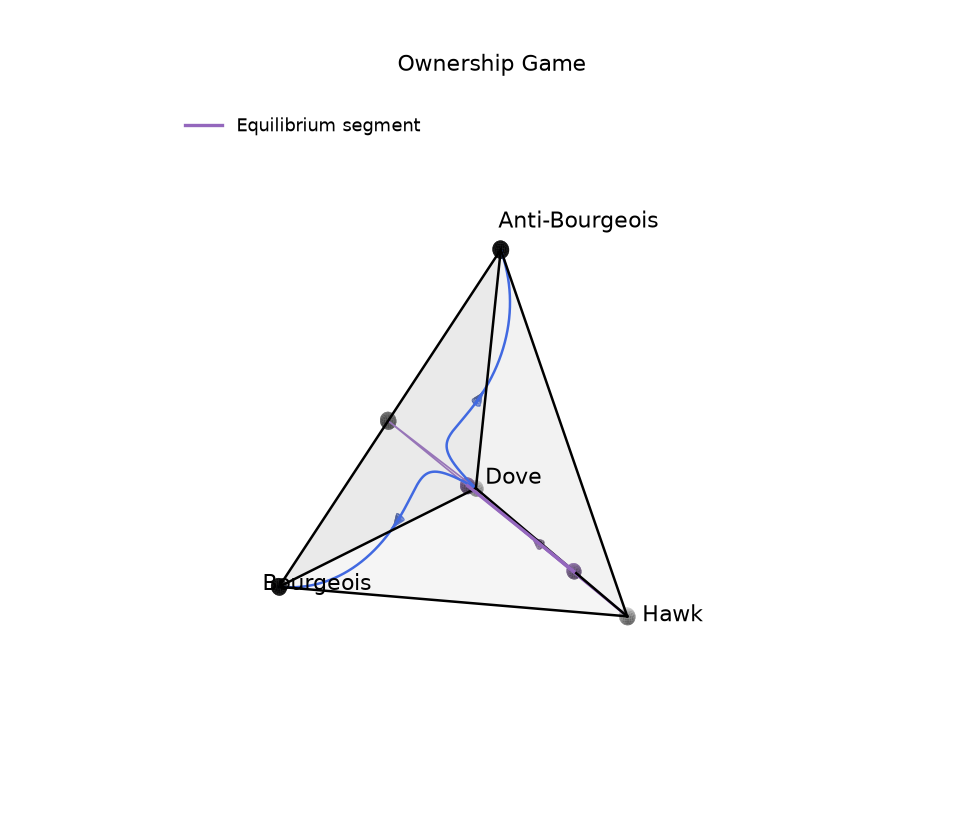

,Position,Stability Status,Nash,ESS,Strict Nash,Eigenvalues,Eigenvectors,Warning
0,"[0.0, 0.0, 0.0, 1.0]",sink,True,True,True,"[-0.25, -0.5, -0.75]","[[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, ...",None
1,"[0.0, 0.0, 0.5, 0.5]",saddle,False,False,False,"[0.375, 0.125, -0.125]","[[0.0, 0.0, 1.0], [0.894427, 0.0, -0.447214], ...",None
2,"[0.0, 0.0, 1.0, 0.0]",sink,True,True,True,"[-0.75, -0.25, -0.5]","[[0.0, 0.0, 1.0], [0.707107, 0.0, -0.707107], ...",None
3,"[0.0, 1.0, 0.0, 0.0]",source,False,False,False,"[0.5, 1.0, 0.5]","[[0.0, 1.0, 0.0], [0.707107, -0.707107, 0.0], ...",None
4,"[1.0, 0.0, 0.0, 0.0]",source,False,False,False,"[0.25, 0.5, 0.25]","[[1.0, 0.0, 0.0], [-0.707107, 0.707107, 0.0], ...",None


In [5]:
plt.close("all")
%matplotlib widget

ownership_game = pn.examples.games.ownership_game

fig, ax = pn.phase_portrait(
    game=ownership_game,
    starts=[
        [0.55, 0.15, 0.15],  # x_B = x_AB: approaches the equilibrium segment
        [0.15, 0.15, 0.55],  # x_B > x_AB: approaches pure Bourgeois
        [0.15, 0.15, 0.15],  # x_B < x_AB: approaches pure Anti-Bourgeois
    ],
    tmax=100,
    trajectory_arrows=[0.001],
    trajectory_color=["tab:purple","royalblue","royalblue"],
    trajectory_linewidth=1.5,
    show_faces=True,
    face_colors=["#f0f0f0", "#d9d9d9", "#bdbdbd", "#969696"],
    face_alpha=0.12,
    view_elev=22,
    view_azim=38,
    figsize=(8, 7),
    equilibrium_size=50
)

# The ownership game has the equilibrium segment
# (x_H, x_D, x_B, x_AB) = (V/C-s, 1-V/C-s, s, s).
s_max = min(V / C, 1 - V / C)
s = np.linspace(0, s_max, 200)
equilibrium_states = np.column_stack([
    V / C - s,
    1 - V / C - s,
    s,
    s,
])

# Convert barycentric population frequencies to pyNamo's tetrahedron coordinates.
def tetrahedron_xyz(states):
    x_H, x_D, x_B = np.asarray(states)[:, :3].T
    return np.column_stack([
        0.5 * (-x_D + x_B + 1),
        np.sqrt(3) / 4 * (x_H - x_D - x_B + 1),
        -np.sqrt(13) / 4 * (x_H + x_D + x_B - 1),
    ])


# The invariant plane x_B = x_AB is the separatrix between the two open basins.
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

separatrix_states = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0.5, 0.5],
], dtype=float)
separatrix_xyz = tetrahedron_xyz(separatrix_states)
separatrix = Poly3DCollection(
    [separatrix_xyz],
    facecolor="tab:purple",
    edgecolor="tab:purple",
    linewidth=1,
    alpha=0.12,
    zorder=4,
)
ax.add_collection3d(separatrix)

equilibrium_xyz = tetrahedron_xyz(equilibrium_states)
ax.plot(
    equilibrium_xyz[:, 0],
    equilibrium_xyz[:, 1],
    equilibrium_xyz[:, 2],
    color="tab:purple",
    linewidth=2,
    zorder=45,
    label="Equilibrium segment",
)

# Highlight both endpoints with purple spheres.
endpoint_radius = 0.022
u = np.linspace(0, 2 * np.pi, 24)
v = np.linspace(0, np.pi, 12)
for center in equilibrium_xyz[[0, -1]]:
    sphere_x = endpoint_radius * np.outer(np.cos(u), np.sin(v)) + center[0]
    sphere_y = endpoint_radius * np.outer(np.sin(u), np.sin(v)) + center[1]
    sphere_z = endpoint_radius * np.outer(np.ones_like(u), np.cos(v)) + center[2]
    ax.plot_surface(
        sphere_x,
        sphere_y,
        sphere_z,
        color="tab:purple",
        linewidth=0,
        antialiased=True,
        shade=True,
        zorder=46,
    )
ax.legend(loc="upper left", frameon=False)
plt.show()
pn.equilibrium_table(game=ownership_game)

The stability table above identifies isolated rest points. It reports only the two pure sinks — Bourgeois and Anti-Bourgeois — because the equilibrium segment is a continuum, and SymPy flags the system as non-isolated rather than enumerating individual points.

The three-dimensional portrait captures global structure, but a single projection is hard to read in full. Each triangular face of the tetrahedron is an invariant set under replicator dynamics, so examining the four three-strategy sub-games gives a complementary view: ESS candidates on each face show up as sinks, and the face portraits together cover every edge and vertex of the tetrahedron.

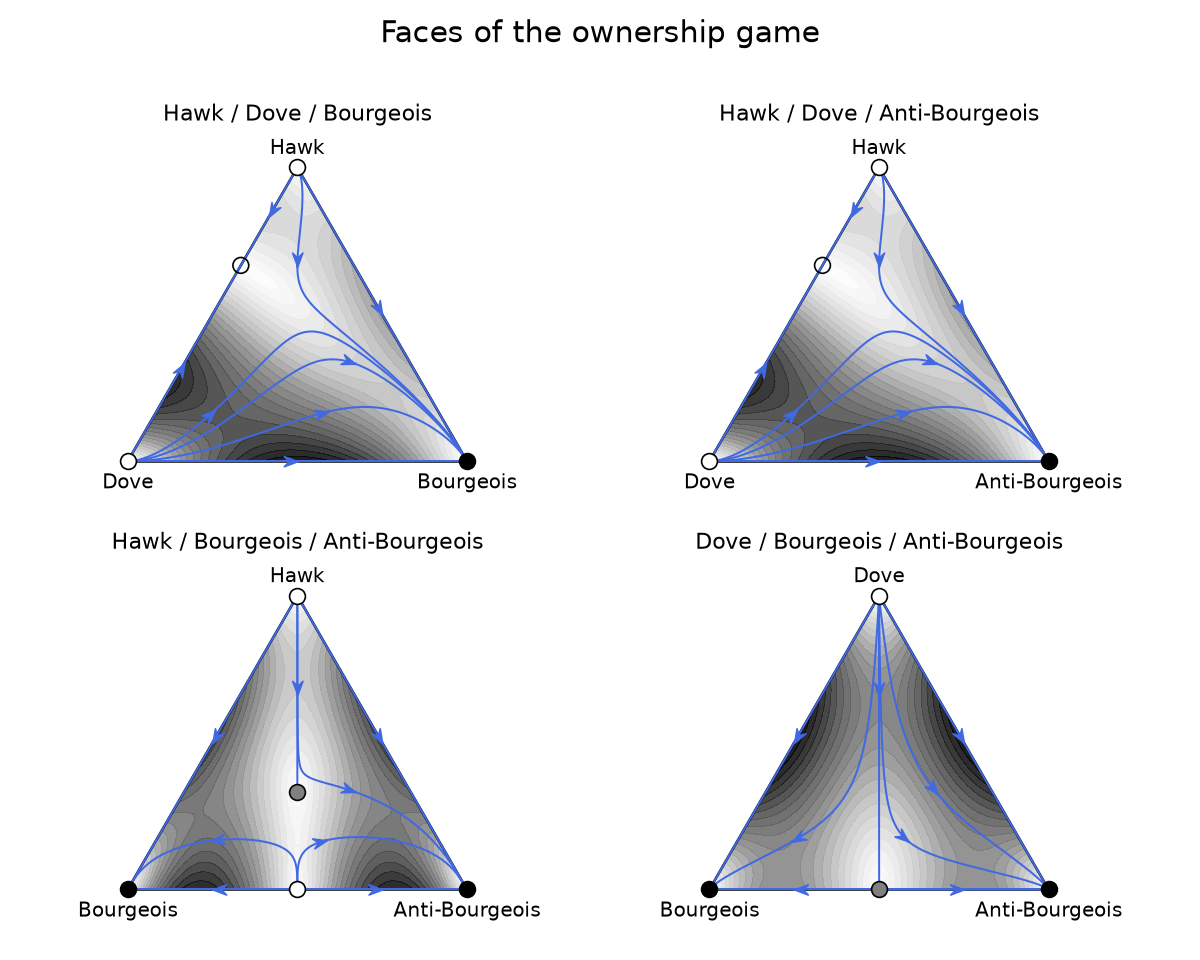

In [8]:
from itertools import combinations

ownership_game = pn.examples.games.ownership_game
payoffs = np.asarray(ownership_game.payoff_data, dtype=float)
labels = ownership_game.strategy_labels

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

for ax, indices in zip(axes.flat, combinations(range(4), 3)):
    face_labels = [labels[i] for i in indices]

    face_game = pn.Game(
        name=" / ".join(face_labels),
        payoffs=payoffs[np.ix_(indices, indices)],
        strategy_labels=face_labels,
    )

    pn.phase_portrait(
        game=face_game,
        fig=fig,
        ax=ax,
        trajectory_number=4,
        show_edge_flow=True,
        tmax=100,
        show_speed=True,
        speed_cmap=plt.cm.Greys,
        speed_levels=20,
        trajectory_arrows=[0.001],
        trajectory_color="royalblue",
        trajectory_linewidth=1.2,
        simplex_font_size=12,
        equilibrium_size=90,
        trajectory_zorder=35
    )
    
fig.suptitle("Faces of the ownership game", fontsize=18)
fig.tight_layout(pad=2)
plt.show()

## Further reading

- Maynard Smith, J. & Price, G. R. (1973). *The logic of animal conflict*. Nature 246, 15–18.

- Maynard Smith, J. (1982). *Evolution and the Theory of Games*. Cambridge University Press.